# 2/3 (v7) — Staged time2success model

Shared encoder, two heads: a T2S regression head and an auxiliary stage
classification head. Only the T2S head is used at inference — the stage head
exists to constrain what the encoder represents.

**Why an auxiliary head rather than a stage input column.** v5 already had an
explicit `holding` feature at index 48 and it changed nothing: the model was
free to ignore it, because in successful-only data the flag is perfectly
predicted by frame index and carries nothing the countdown target needs. A
head is different in kind — the encoder must represent phase to minimise the
stage loss, so the T2S head reads from a representation that already
distinguishes pre- from post-control.

**Why this might still fail, stated in advance.** v7's stage label is
frame-predictable at 94-99% on the competent checkpoints and only 9-11% on the
early/random ones. If competent rows dominate the mix, the stage head can
satisfy most of its loss with a clock and the constraint never bites. Section 3
weights the loss to counter that, and Section 7 measures whether it worked.

## 1. Setup

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import metaworld
import os, json, pickle, glob
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39
N_STAGES = 3

HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]

DATASET_DIR = "./data/state_space_datasetV7"
MODEL_DIR   = "./checkpoints/t2s_staged_v7"
os.makedirs(MODEL_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cpu


In [2]:
def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

def find_wrapper(env, attr):
    w = env
    while not hasattr(w, attr):
        if not hasattr(w, "env"):
            raise AttributeError(attr)
        w = w.env
    return w

FIXED_TASK_PATH = os.path.join(DATASET_DIR, "fixed_task.pkl")

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        env.unwrapped.set_task(pickle.load(f))
    return env

ckpts = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
               key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))
numbered = [p for p in ckpts if any(c.isdigit() for c in os.path.basename(p))]
FINAL_CKPT = [p for p in ckpts if "final" in os.path.basename(p)][0]
EARLY_CKPT = numbered[0]
expert_pol, early_pol = SAC.load(FINAL_CKPT), SAC.load(EARLY_CKPT)
print("expert:", os.path.basename(FINAL_CKPT), "| early:", os.path.basename(EARLY_CKPT))

expert: sac_peg_insert_final.zip | early: sac_peg_insert_100000.zip


## 2. Load the dataset

In [3]:
data = np.load(os.path.join(DATASET_DIR, "dataset.npz"))
X, y_steps = data["X"], data["y_steps"]
stage, episode_ids, frame_idxs = data["stage"], data["episode_ids"], data["frame_idxs"]

with open(os.path.join(DATASET_DIR, "dataset_summary.json")) as f:
    print(json.dumps(json.load(f), indent=2))

assert X.shape[1] == OBS_DIM, f"expected {OBS_DIM} columns, got {X.shape[1]}"
print(f"\n{X.shape[0]} rows, {len(np.unique(episode_ids))} episodes")
for k in range(N_STAGES):
    print(f"  stage {k}: {(stage == k).mean():.1%}")

{
  "total_rows": 106000,
  "total_episodes": 212,
  "obs_dim": 39,
  "dt_sec": 0.0125,
  "successful_episodes": 128,
  "failed_episodes": 84,
  "control_detected": 128,
  "censor_label": 300.0,
  "label_anchor": "first_success_frame, flat 0 plateau to end of episode",
  "stage_definition": "0 pre-control, 1 control, 2 complete; onset from hand-object coupling, not a grasp predicate",
  "stage_fractions": {
    "0": 0.4120377358490566,
    "1": 0.0615,
    "2": 0.5264622641509434
  },
  "detector": {
    "vel_window": 5,
    "vel_cos_thresh": 0.7,
    "vel_min_motion": 0.0003,
    "pose_window": 5,
    "pose_std_thresh": 0.002,
    "confirm_frames": 2
  },
  "sources": [
    "random_n0.0",
    "sac_peg_insert_100000.zip_n0.0",
    "sac_peg_insert_100000.zip_n0.15",
    "sac_peg_insert_100000.zip_n0.4",
    "sac_peg_insert_400000.zip_n0.0",
    "sac_peg_insert_400000.zip_n0.15",
    "sac_peg_insert_400000.zip_n0.4",
    "sac_peg_insert_final.zip_n0.0",
    "sac_peg_insert_final.zip_n0.1

## 3. Split, normalize, and weight

Group split by episode — adjacent frames are near-identical, so a row-level
split leaks.

The per-row weight counters the mix problem. Rows whose stage is *not* what a
frame counter would predict are the ones carrying information beyond position
along the path, so they get more weight. Without this, the 94-99%
clock-predictable rows from the competent checkpoints dominate and the stage
head learns a clock.

In [4]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=0)
tr, va = next(gss.split(X, y_steps, groups=episode_ids))

x_mean, x_std = X[tr].mean(axis=0), X[tr].std(axis=0) + 1e-8
y_mean, y_std = y_steps[tr].mean(), y_steps[tr].std()

Xn = ((X - x_mean) / x_std).astype(np.float32)
yn = ((y_steps - y_mean) / y_std).astype(np.float32)

# what a frame counter would guess, per frame index, from the training rows
from collections import Counter
mode_by_frame = {}
for t in np.unique(frame_idxs[tr]):
    rows = tr[frame_idxs[tr] == t]
    mode_by_frame[t] = Counter(stage[rows].tolist()).most_common(1)[0][0]
clock_guess = np.array([mode_by_frame.get(t, 0) for t in frame_idxs])

HARD_WEIGHT = 4.0      # rows a clock gets wrong
row_w = np.where(clock_guess == stage, 1.0, HARD_WEIGHT).astype(np.float32)
print(f"rows a frame counter gets wrong: {(clock_guess != stage).mean():.1%} "
      f"(weighted x{HARD_WEIGHT})")
print(f"effective weight mass on those rows: "
      f"{row_w[clock_guess != stage].sum() / row_w.sum():.1%}")

rows a frame counter gets wrong: 38.9% (weighted x4.0)
effective weight mass on those rows: 71.8%


## 4. Model — shared encoder, two heads

In [5]:
class StagedTime2SuccessModel(nn.Module):
    # model structure: obs -> encoder -> (t2s_head, stage_head)
    def __init__(self, obs_dim, hidden=256, dropout=0.2, n_stages=N_STAGES):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
        )
        self.t2s_head   = nn.Linear(hidden, 1)
        self.stage_head = nn.Linear(hidden, n_stages)

    def forward(self, x):
        h = self.encoder(x)
        return self.t2s_head(h).squeeze(-1), self.stage_head(h)

    def predict_t2s_only(self, x):
        return self.t2s_head(self.encoder(x)).squeeze(-1)

## 5. Train

In [7]:
STAGE_W = 0.5          # weight on the auxiliary stage loss
EPOCHS, PATIENCE = 300, 30

def loader(rows, shuffle):
    return DataLoader(TensorDataset(
        torch.tensor(Xn[rows]), torch.tensor(yn[rows]),
        torch.tensor(stage[rows]), torch.tensor(row_w[rows])),
        batch_size=256, shuffle=shuffle)

train_loader, val_loader = loader(tr, True), loader(va, False)

torch.manual_seed(0); np.random.seed(0)
model = StagedTime2SuccessModel(obs_dim=OBS_DIM).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

best, stale = float("inf"), 0
hist = []
for ep in range(EPOCHS):
    model.train()
    for xb, yb, sb, wb in train_loader:
        xb, yb, sb, wb = xb.to(device), yb.to(device), sb.to(device), wb.to(device)
        opt.zero_grad()
        t2s, logits = model(xb)
        l_t2s   = (wb * (t2s - yb) ** 2).mean()
        l_stage = (wb * F.cross_entropy(logits, sb, reduction="none")).mean()
        (l_t2s + STAGE_W * l_stage).backward()
        opt.step()

    model.eval()
    vt = vs = vacc = n = 0.0
    with torch.no_grad():
        for xb, yb, sb, wb in val_loader:
            xb, yb, sb = xb.to(device), yb.to(device), sb.to(device)
            t2s, logits = model(xb)
            b = xb.size(0)
            vt   += F.mse_loss(t2s, yb).item() * b
            vs   += F.cross_entropy(logits, sb).item() * b
            vacc += (logits.argmax(1) == sb).float().sum().item()
            n    += b
    vt, vs, vacc = vt / n, vs / n, vacc / n
    hist.append((ep, vt, vs, vacc))

    # early stopping tracks the T2S head — that is what the reward uses
    if vt < best:
        best, stale = vt, 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "model.pt"))
    else:
        stale += 1
        if stale >= PATIENCE:
            break
    if ep % 20 == 0:
        print(f"epoch {ep:3d}: val t2s MSE={vt:.4f}  stage CE={vs:.4f}  stage acc={vacc:.1%}")

print(f"\nbest val T2S MSE(norm)={best:.4f}, stopped epoch {ep}")
np.savez(os.path.join(MODEL_DIR, "normalization.npz"),
         X_mean=x_mean, X_std=x_std, y_mean=y_mean, y_std=y_std)
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "model.pt")))
model.eval()
print(f"saved to {MODEL_DIR}")

epoch   0: val t2s MSE=0.0281  stage CE=0.0313  stage acc=99.3%
epoch  20: val t2s MSE=0.0116  stage CE=0.0474  stage acc=98.0%
epoch  40: val t2s MSE=0.0118  stage CE=0.0342  stage acc=98.8%
epoch  60: val t2s MSE=0.0097  stage CE=0.0255  stage acc=99.2%
epoch  80: val t2s MSE=0.0081  stage CE=0.0380  stage acc=98.8%
epoch 100: val t2s MSE=0.0136  stage CE=0.0343  stage acc=98.8%

best val T2S MSE(norm)=0.0077, stopped epoch 102
saved to ./checkpoints/t2s_staged_v7


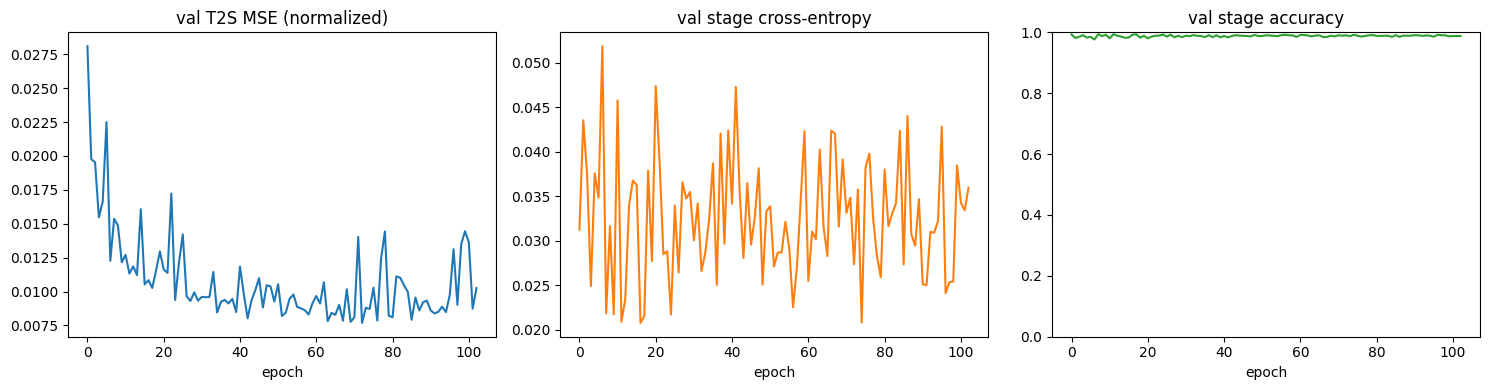

In [8]:
h = np.array(hist)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(h[:, 0], h[:, 1]); axes[0].set_title("val T2S MSE (normalized)")
axes[1].plot(h[:, 0], h[:, 2], color="tab:orange"); axes[1].set_title("val stage cross-entropy")
axes[2].plot(h[:, 0], h[:, 3], color="tab:green"); axes[2].set_title("val stage accuracy")
axes[2].set_ylim(0, 1)
for ax in axes: ax.set_xlabel("epoch")
plt.tight_layout(); plt.show()

## 6. Prediction helper

In [9]:
PRED_CLIP_MAX = 300.0

@torch.no_grad()
def predict(obs, clip=True):
    """Returns (predicted steps remaining, stage probabilities).
    The reward wrapper uses only the first value."""
    x = torch.tensor((np.asarray(obs, dtype=np.float32) - x_mean) / x_std,
                      dtype=torch.float32).unsqueeze(0).to(device)
    t2s, logits = model(x)
    p = float(t2s.item() * y_std + y_mean)
    if clip:
        p = float(np.clip(p, 0.0, PRED_CLIP_MAX))
    return p, F.softmax(logits, dim=1).cpu().numpy()[0]

def predict_t2s(obs, clip=True):
    return predict(obs, clip)[0]

_o, _ = make_fixed_scene_env().reset()
_p, _s = predict(_o)
print(f"at reset: pred={_p:.1f} steps, stage probs={np.round(_s, 3)}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


at reset: pred=172.1 steps, stage probs=[0.991 0.009 0.   ]


## 7. Did the stage head change anything?

Three checks, in order of how directly they bear on the RL outcome.

**(a) Stage accuracy against the clock baseline.** If the head only matches
what a frame counter achieves, it learned a clock and the encoder is unchanged.

**(b) The failing-rollout minimum.** The number that has tracked RL behaviour
throughout. Successful-only models read ~15 there; the v6 off-path model read
~300. Anything well above 15 means the model is not mistaking a stall for
near-success.

**(c) Stage probabilities during a stalled rollout.** The specific claim being
tested is that the model now says "hand is close, but this is pre-control."
If stage 0 stays high while the arm hovers, that is the claim confirmed
directly.

In [10]:
# (a)
with torch.no_grad():
    xb = torch.tensor(Xn[va]).to(device)
    _, logits = model(xb)
    pred_stage = logits.argmax(1).cpu().numpy()
head_acc  = (pred_stage == stage[va]).mean()
clock_acc = (clock_guess[va] == stage[va]).mean()
print(f"stage head accuracy : {head_acc:.1%}")
print(f"clock baseline      : {clock_acc:.1%}")
print(f"margin over clock   : {head_acc - clock_acc:+.1%}  "
      f"(near zero means the head learned a clock)")

stage head accuracy : 99.0%
clock baseline      : 60.3%
margin over clock   : +38.7%  (near zero means the head learned a clock)


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


expert : success at 48, min pred=0.0
failing: min pred=172.1   <-- the number that matters
random : min pred=172.1

reference: successful-only models read ~15 on the failing rollout;
the v6 off-path model read ~300.


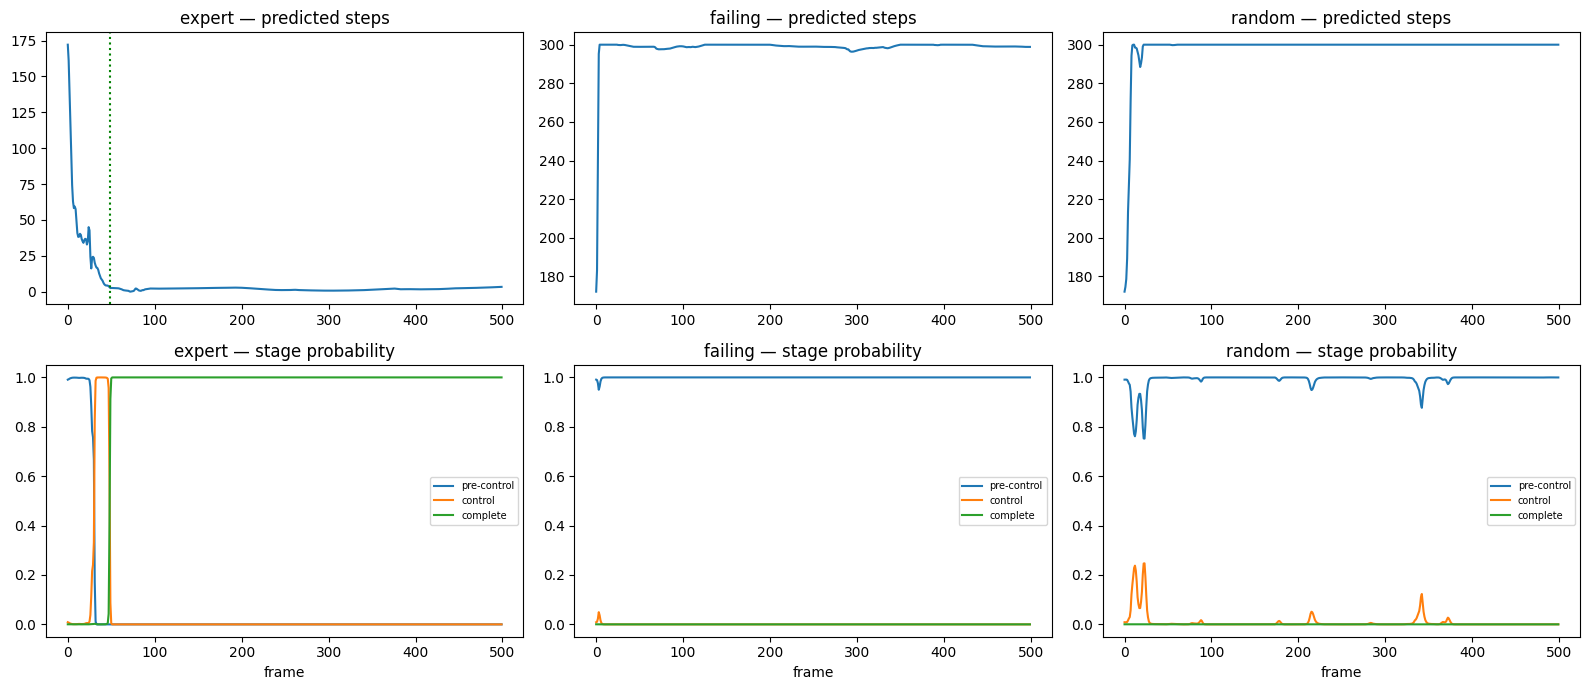

In [11]:
# (b) and (c)
def rollout(policy, max_steps=500, random_policy=False):
    env = make_fixed_scene_env()
    obs, _ = env.reset()
    preds, stages, success = [], [], None
    for t in range(max_steps):
        p, sp = predict(obs)
        preds.append(p); stages.append(sp)
        a = env.action_space.sample() if random_policy else \
            policy.predict(obs, deterministic=True)[0]
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    return np.array(preds), np.array(stages), success

p_exp, s_exp, succ = rollout(expert_pol)
p_fail, s_fail, _  = rollout(early_pol)
p_rand, s_rand, _  = rollout(None, random_policy=True)

print(f"expert : success at {succ}, min pred={p_exp.min():.1f}")
print(f"failing: min pred={p_fail.min():.1f}   <-- the number that matters")
print(f"random : min pred={p_rand.min():.1f}")
print("\nreference: successful-only models read ~15 on the failing rollout;")
print("the v6 off-path model read ~300.")

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for col, (name, p, s, sc) in enumerate([
        ("expert", p_exp, s_exp, succ), ("failing", p_fail, s_fail, None),
        ("random", p_rand, s_rand, None)]):
    axes[0, col].plot(p); axes[0, col].set_title(f"{name} — predicted steps")
    if sc is not None:
        axes[0, col].axvline(sc, color="green", ls=":")
    for k, lab in enumerate(["pre-control", "control", "complete"]):
        axes[1, col].plot(s[:, k], label=lab)
    axes[1, col].set_title(f"{name} — stage probability")
    axes[1, col].set_xlabel("frame"); axes[1, col].legend(fontsize=7)
plt.tight_layout(); plt.show()

Validate labels

In [12]:
CENSOR_LABEL = 300.0

failed_eps = set()
for ep in np.unique(episode_ids):
    if np.all(y_steps[episode_ids == ep] == CENSOR_LABEL):
        failed_eps.add(int(ep))

val_eps = set(episode_ids[va].tolist())
print(f"failed episodes total: {len(failed_eps)}")
print(f"failed episodes in validation split: {len(failed_eps & val_eps)}")

failed episodes total: 84
failed episodes in validation split: 13


In [13]:
from sklearn.metrics import classification_report

fail_mask = np.isin(episode_ids[va], list(failed_eps & val_eps))
print(f"validation rows from failed episodes: {fail_mask.sum()} of {len(va)}")
print(classification_report(stage[va][fail_mask], pred_stage[fail_mask],
                             labels=[0, 1, 2],
                             target_names=["pre-control", "control", "complete"],
                             zero_division=0))

validation rows from failed episodes: 6500 of 16000
              precision    recall  f1-score   support

 pre-control       1.00      0.98      0.99      6500
     control       0.00      0.00      0.00         0
    complete       0.00      0.00      0.00         0

    accuracy                           0.98      6500
   macro avg       0.33      0.33      0.33      6500
weighted avg       1.00      0.98      0.99      6500



## 8. Ranking check

Pre-success frames only — including the post-anchor zeros creates a large tied
block that depresses Spearman for reasons unrelated to model quality.

In [14]:
rhos = []
for seed in range(500, 515):
    env = make_fixed_scene_env()
    obs, _ = env.reset(seed=seed)
    preds, ss = [], None
    for t in range(500):
        preds.append(predict_t2s(obs))
        a, _ = expert_pol.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0):
            ss = t; break
        if term or trunc: break
    env.close()
    if ss is None or len(preds) < 10:
        continue
    rho, _ = spearmanr(preds, [ss - t for t in range(len(preds))])
    rhos.append(rho)
rhos = np.array(rhos)
print(f"pre-success Spearman: mean={rhos.mean():.3f}, min={rhos.min():.3f}, "
      f"below 0.7: {(rhos < 0.7).sum()}/{len(rhos)}")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


pre-success Spearman: mean=0.973, min=0.973, below 0.7: 0/15


## 9. Next

If (a) shows a real margin over the clock and (b) keeps the failing rollout
high, point notebook 3's `T2S_MODEL_DIR` at `./checkpoints/t2s_staged_v7` and
re-run its Section 5 reward inspection before training. Note notebook 3
constructs a single-head `Time2SuccessModel`, so it needs the
`StagedTime2SuccessModel` class and a `predict_t2s` that reads only the T2S
head — the class definition and helper from Sections 4 and 6 above.

If (a) shows no margin, the stage head learned a clock and the encoder is
unchanged. Raising `HARD_WEIGHT` or collecting a larger share of off-path
episodes are the levers before concluding the approach does not bite.

## 10. Side-by-side trajectory prediction

Records a successful and a failed rollout with video, and puts the T2S
prediction, the stage posterior, and the physical coupling signals on a shared
frame axis. The coupling rows are what the stage labels were derived from, so
this shows whether the posterior tracks the physics it was meant to learn —
not only whether it reproduces the labels.

In [15]:
import imageio
from IPython.display import Video

# Detector settings are read from the dataset summary rather than restated, so
# this cannot silently diverge from the labels the model was trained on.
with open(os.path.join(DATASET_DIR, "dataset_summary.json")) as f:
    _det = json.load(f)["detector"]
VEL_WINDOW      = _det["vel_window"]
VEL_COS_THRESH  = _det["vel_cos_thresh"]
VEL_MIN_MOTION  = _det["vel_min_motion"]
POSE_WINDOW     = _det["pose_window"]
POSE_STD_THRESH = _det["pose_std_thresh"]
CONFIRM_FRAMES  = _det["confirm_frames"]
print("detector settings from the dataset:", _det)

def coupling_signals(obs_seq):
    hand = obs_seq[:, HAND_POS_IDX]
    peg  = obs_seq[:, PEG_POS_IDX]
    T = len(obs_seq)
    dh, dp = np.diff(hand, axis=0), np.diff(peg, axis=0)
    cos = np.zeros(T, dtype=np.float32)
    for t in range(T - 1 - VEL_WINDOW):
        h, p = dh[t:t+VEL_WINDOW].ravel(), dp[t:t+VEL_WINDOW].ravel()
        nh, npg = np.linalg.norm(h), np.linalg.norm(p)
        cos[t + VEL_WINDOW] = 0.0 if (nh < VEL_MIN_MOTION or npg < VEL_MIN_MOTION) \
                                  else float(h @ p / (nh * npg))
    rel = peg - hand
    pose_std = np.full(T, np.inf, dtype=np.float32)
    for t in range(POSE_WINDOW, T):
        pose_std[t] = rel[t-POSE_WINDOW:t].std(axis=0).mean()
    return cos, pose_std

detector settings from the dataset: {'vel_window': 5, 'vel_cos_thresh': 0.7, 'vel_min_motion': 0.0003, 'pose_window': 5, 'pose_std_thresh': 0.002, 'confirm_frames': 2}


In [16]:
def rollout_full(policy, out_path, max_steps=500, deterministic=True,
                 random_policy=False, seed=None):
    env = make_fixed_scene_env(render_mode="rgb_array")
    obs, _ = env.reset(seed=seed)
    frames, preds, stages, obs_seq = [], [], [], []
    success = None
    for t in range(max_steps):
        frames.append(env.render())
        obs_seq.append(obs.copy())
        p, sp = predict(obs)
        preds.append(p); stages.append(sp)
        action = env.action_space.sample() if random_policy else \
                 policy.predict(obs, deterministic=deterministic)[0]
        obs, _, term, trunc, info = env.step(action)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    imageio.mimsave(out_path, frames, fps=20)

    obs_seq = np.array(obs_seq, dtype=np.float32)
    cos, pose_std = coupling_signals(obs_seq)
    return dict(preds=np.array(preds), stages=np.array(stages), obs=obs_seq,
                cos=cos, pose_std=pose_std, success=success,
                n=len(frames), path=out_path)

success_run = rollout_full(expert_pol, "v7_success.mp4", seed=0)
failure_run = rollout_full(early_pol,  "v7_failure.mp4", seed=0)

for name, r in [("success", success_run), ("failure", failure_run)]:
    st = r["stages"].argmax(1)
    print(f"{name:8s}: {r['n']:3d} frames, success at {r['success']}, "
          f"pred {r['preds'][0]:.0f} -> {r['preds'][-1]:.0f} "
          f"(min {r['preds'].min():.1f}), "
          f"stage fractions {[round(float((st == k).mean()), 3) for k in range(N_STAGES)]}")

success : 500 frames, success at 48, pred 172 -> 3 (min 0.0), stage fractions [0.062, 0.036, 0.902]
failure : 500 frames, success at None, pred 172 -> 299 (min 172.1), stage fractions [1.0, 0.0, 0.0]


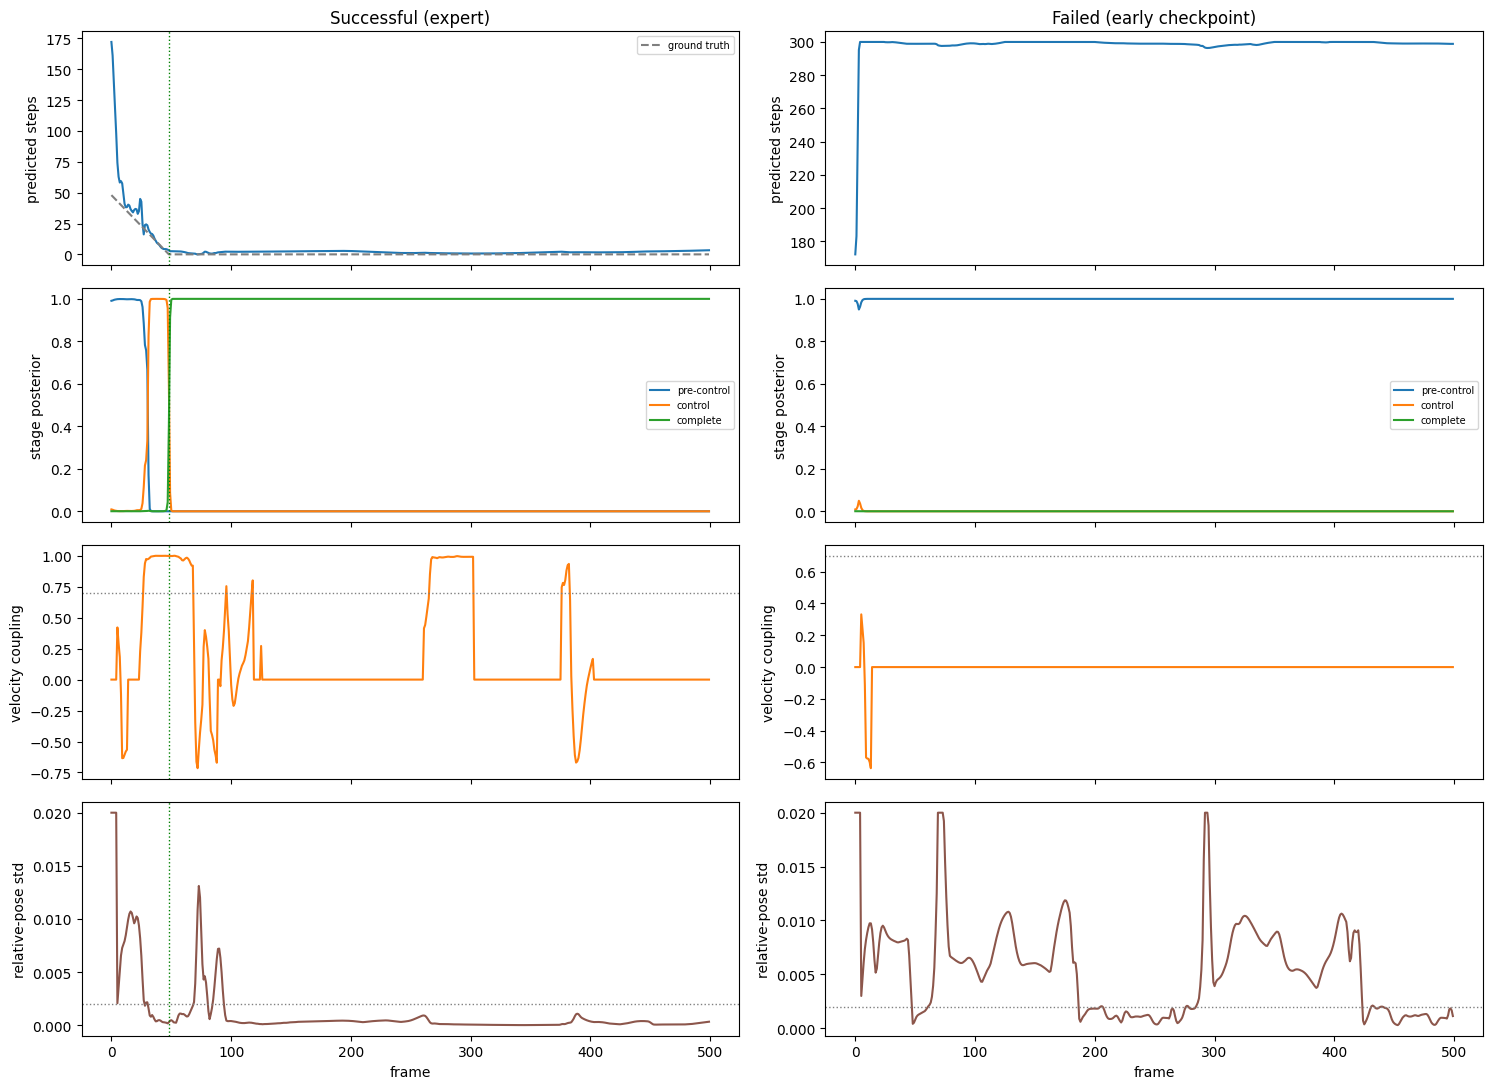

Rows 3-4 are the physics the labels came from. Where the posterior in
row 2 tracks them, the head learned coupling rather than trajectory position.


In [17]:
fig, axes = plt.subplots(4, 2, figsize=(15, 11), sharex="col")
runs = [("Successful (expert)", success_run), ("Failed (early checkpoint)", failure_run)]

for col, (title, r) in enumerate(runs):
    n = r["n"]

    axes[0, col].plot(r["preds"], color="tab:blue")
    if r["success"] is not None:
        axes[0, col].plot([max(0, r["success"] - t) for t in range(n)], "--",
                           color="tab:gray", label="ground truth")
        axes[0, col].legend(fontsize=7)
    axes[0, col].set_title(title)
    axes[0, col].set_ylabel("predicted steps")

    for k, lab in enumerate(["pre-control", "control", "complete"]):
        axes[1, col].plot(r["stages"][:, k], label=lab)
    axes[1, col].set_ylabel("stage posterior"); axes[1, col].set_ylim(-0.05, 1.05)
    axes[1, col].legend(fontsize=7)

    axes[2, col].plot(r["cos"], color="tab:orange")
    axes[2, col].axhline(VEL_COS_THRESH, color="gray", ls=":", lw=1)
    axes[2, col].set_ylabel("velocity coupling")

    axes[3, col].plot(np.clip(r["pose_std"], 0, 0.02), color="tab:brown")
    axes[3, col].axhline(POSE_STD_THRESH, color="gray", ls=":", lw=1)
    axes[3, col].set_ylabel("relative-pose std")
    axes[3, col].set_xlabel("frame")

    for row in range(4):
        if r["success"] is not None:
            axes[row, col].axvline(r["success"], color="green", ls=":", lw=1)

plt.tight_layout(); plt.show()
print("Rows 3-4 are the physics the labels came from. Where the posterior in")
print("row 2 tracks them, the head learned coupling rather than trajectory position.")

In [ ]:
Video("v7_success.mp4", embed=True)

In [ ]:
Video("v7_failure.mp4", embed=True)

### Posterior vs. detector

The head is trained on detector labels, so on held-out rollouts it should
reproduce them. Divergence means it is keying on something else.

In [18]:
def detector_stage(r):
    cand = (r["cos"] > VEL_COS_THRESH) & (r["pose_std"] < POSE_STD_THRESH)
    onset, run = None, 0
    for t in range(len(cand)):
        run = run + 1 if cand[t] else 0
        if run >= CONFIRM_FRAMES:
            onset = t - CONFIRM_FRAMES + 1
            break
    s = np.zeros(r["n"], dtype=np.int64)
    if onset is not None:
        s[onset:] = 1
    if r["success"] is not None:
        s[r["success"]:] = 2
    return s, onset

for name, r in [("success", success_run), ("failure", failure_run)]:
    ref, onset = detector_stage(r)
    pred = r["stages"].argmax(1)
    head_onset = int(np.argmax(pred >= 1)) if (pred >= 1).any() else None
    print(f"{name:8s}: agreement={float((pred == ref).mean()):.1%}  "
          f"detector onset={onset}  head onset={head_onset}")

success : agreement=99.8%  detector onset=31  head onset=31
failure : agreement=100.0%  detector onset=None  head onset=None
